In [1]:
import glob, json
import pandas as pd


files = glob.glob(r"E:\Aaron\Cong_Speeches\App_developement\v3\cora-client-server-poc\cora-backend\data\speeches_*.jsonl")
#files = glob.glob("data/speeches_*.jsonl")

rows = []
for fp in files:
    # Specify utf-8 encoding
    with open(fp, "r", encoding="utf-8", errors="replace") as f:
        for line in f:
            try:
                rows.append(json.loads(line))
            except json.JSONDecodeError:
                # If a line is corrupted, skip or log it
                continue

df = pd.DataFrame(rows)

# Senate only, 1873–2025
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year

df = df[
    (df['chamber'] == 'Senate') &
    (df['year'].between(1873, 2025)) &
    (df['speaker_gender'].isin(['M', 'F']))
].copy()





In [2]:
# number of words cut off
df = df[df['speaking'].str.split().str.len() >= 50]

In [3]:
df['speaker_gender'].value_counts(normalize=True)


speaker_gender
M    0.988459
F    0.011541
Name: proportion, dtype: float64

In [4]:
male_speeches = df[df['speaker_gender'] == 'M']
female_speeches = df[df['speaker_gender'] == 'F']


In [5]:
len(male_speeches), len(female_speeches)


(2322636, 27119)

In [6]:
# Load scores.. made from 1-Validate-Fig2.ipynb
scores = pd.read_csv("Scores_CORRECTED.csv", encoding="utf-8-sig")

# Convert id type to string in both dataframes
df['id'] = df['id'].astype(str)
scores['id'] = scores['id'].astype(str)

# Merge
df = df.merge(scores[['id', 'feminine_index', 'masculine_index']], on='id', how='left')

df["feminine_index"]  = -df["feminine_index"]
df["masculine_index"] = -df["masculine_index"]

# Now summary works
summary = df.groupby('speaker_gender')[['feminine_index', 'masculine_index']].mean()
print(summary)


C:\Users\sr3987\AppData\Local\Temp\ipykernel_26124\3677516903.py:2: DtypeWarning: Columns (8,9,10) have mixed types. Specify dtype option on import or set low_memory=False.
  scores = pd.read_csv("Scores_CORRECTED.csv", encoding="utf-8-sig")


                feminine_index  masculine_index
speaker_gender                                 
F                     0.392518        -0.020665
M                    -0.004583         0.000241


In [7]:
male_speeches = df[df['speaker_gender'] == 'M']
female_speeches = df[df['speaker_gender'] == 'F']


In [8]:
import numpy as np

def cohens_d(group1, group2):
    x1 = group1.values
    x2 = group2.values
    n1 = x1.size
    n2 = x2.size
    mean1 = x1.mean()
    mean2 = x2.mean()
    var1 = x1.var(ddof=1)
    var2 = x2.var(ddof=1)
    pooled_var = ((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2)
    d = (mean1 - mean2) / np.sqrt(pooled_var)
    return d

# Make subsets AFTER merge
male_speeches = df[df['speaker_gender'] == 'M']
female_speeches = df[df['speaker_gender'] == 'F']

# Compute effect sizes
d_fem = cohens_d(male_speeches['feminine_index'],
                 female_speeches['feminine_index'])

d_masc = cohens_d(male_speeches['masculine_index'],
                  female_speeches['masculine_index'])

print("Cohen's d (male − female) feminine:", d_fem)
print("Cohen's d (male − female) masculine:", d_masc)


Cohen's d (male − female) feminine: -0.10479012434026114
Cohen's d (male − female) masculine: 0.009522469321965446


In [9]:
from scipy.stats import ttest_ind

t_fem, p_fem = ttest_ind(
    male_speeches['feminine_index'],
    female_speeches['feminine_index'],
    equal_var=True
)

t_masc, p_masc = ttest_ind(
    male_speeches['masculine_index'],
    female_speeches['masculine_index'],
    equal_var=True
)

print("Feminine t, p:", t_fem, p_fem)
print("Masculine t, p:", t_masc, p_masc)


Feminine t, p: -17.156807425200064 5.642463206550455e-66
Masculine t, p: 1.5590703169589297 0.1189798728909479


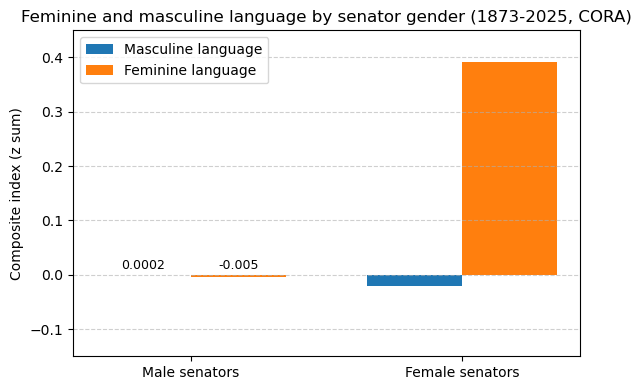

In [46]:
import matplotlib.pyplot as plt
import numpy as np

means = summary  # index: 'M','F' and columns: feminine_index, masculine_index
genders = ['M', 'F']
x = np.arange(2)
width = 0.35

color_masc = 'tab:blue'
color_fem  = 'tab:orange'

fig, ax = plt.subplots(figsize=(6, 4))

# Bars
masc_vals = means.loc[genders, 'masculine_index'].values
fem_vals  = means.loc[genders, 'feminine_index'].values

ax.bar(x - width/2, masc_vals, width, label='Masculine language', color=color_masc)
ax.bar(x + width/2, fem_vals,  width, label='Feminine language',  color=color_fem)

# Labels and styling
ax.set_xticks(x)
ax.set_xticklabels(['Male senators', 'Female senators'])
ax.set_ylabel('Composite index (z sum)')
ax.set_title('Feminine and masculine language by senator gender (1873-2025, CORA)')
ax.legend(loc='upper left')

# Global y-range (your choice)
ax.set_ylim(-0.15, 0.45)

# Zero reference line (helps when values are near zero)
ax.grid(axis='y', linestyle='--', alpha=0.6)

# Annotate small bars
threshold = 0.02
for i, v in enumerate(masc_vals):
    if abs(v) < threshold:
        ax.text(x[i] - width/2, 0.01, f"{v:.4f}", ha='center', fontsize=9)

for i, v in enumerate(fem_vals):
    if abs(v) < threshold:
        ax.text(x[i] + width/2, 0.01, f"{v:.3f}", ha='center', fontsize=9)

plt.tight_layout()
fig.savefig("topic_valid_lan_gend.png", dpi=300, bbox_inches='tight')
plt.show()


In [48]:
# --------------------------------------------------
# Export plot data to CSV
# --------------------------------------------------

export_df = (
    means
    .loc[genders, ['masculine_index', 'feminine_index']]
    .reset_index()
    .rename(columns={'index': 'speaker_gender'})
)

export_df.to_csv(
    "cora_1873_2025.csv",
    index=False,
    encoding="utf-8"
)


OSError: Cannot save file into a non-existent directory: 'Full_Data_Validation'